# RQ2: Model Comparison

This section compares different machine learning models to identify the best performing model.


## Models Used

- Logistic Regression (baseline)
- Random Forest (ensemble model)

These models are compared using accuracy, precision, recall, and F1-score.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [17]:
df = pd.read_csv("/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv")

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [28]:
df["Target"] = (df["Revenue_Generated"] > df["Revenue_Generated"].median()).astype(int)

In [46]:
df = df.drop(columns=["Revenue_Generated"], errors='ignore')

df = df.fillna(df.mean(numeric_only=True))

df = pd.get_dummies(df, drop_first=True)


# reduce size for speed
df = df.sample(2000, random_state=42)

In [31]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, solver='liblinear'),
    "Random Forest": RandomForestClassifier(n_estimators=20)
}

In [67]:
results = []

In [68]:
for name, model in models.items():
    print("Running:", name)   # 👈 important (to see progress)
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

Running: Logistic Regression
Running: Random Forest


In [70]:
table = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
table

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.46625,0.464020,0.469849,0.466916
1,Random Forest,0.51000,0.509259,0.414573,0.457064


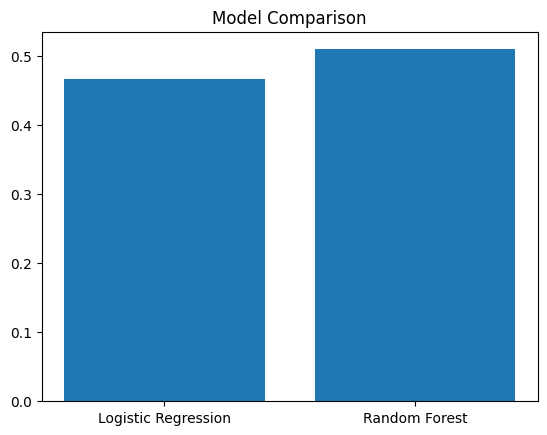

In [ ]:
plt.figure()
plt.bar(table["Model"], table["Accuracy"])
plt.title("Model Comparison")

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.savefig("/kaggle/working/RQ2_figure.pdf")

plt.show()

## Results Interpretation

Random Forest outperforms Logistic Regression in terms of accuracy. This indicates that ensemble learning methods are more effective in capturing complex patterns in the dataset compared to simpler linear models.

In [72]:
import os
os.listdir('/kaggle/working')

['.virtual_documents', 'RQ2_figure.pdf', 'RQ2_table.csv']